# Classificazione studenti

**Import libraries**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Dataset**

In [2]:
columns = ['College_ID', 'IQ', 'CGPA', 'Prev_Sem_Result', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']

df = pd.read_csv('../data/processed/college_student_placement_clean.csv')
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


**Operazioni sul dataset**

In [3]:
from sklearn.preprocessing import OrdinalEncoder

X = df.drop(columns=['Placement'])
y = df['Placement']

enc = OrdinalEncoder()
X['College_ID'] = enc.fit_transform(X[['College_ID']])

X.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,29.0,107,6.61,6.28,8,0,8,8,4
1,60.0,97,5.52,5.37,8,0,7,8,0
2,35.0,109,5.36,5.83,9,0,3,1,1
3,54.0,122,5.47,5.75,6,1,1,6,1
4,3.0,96,7.91,7.69,7,0,8,10,2


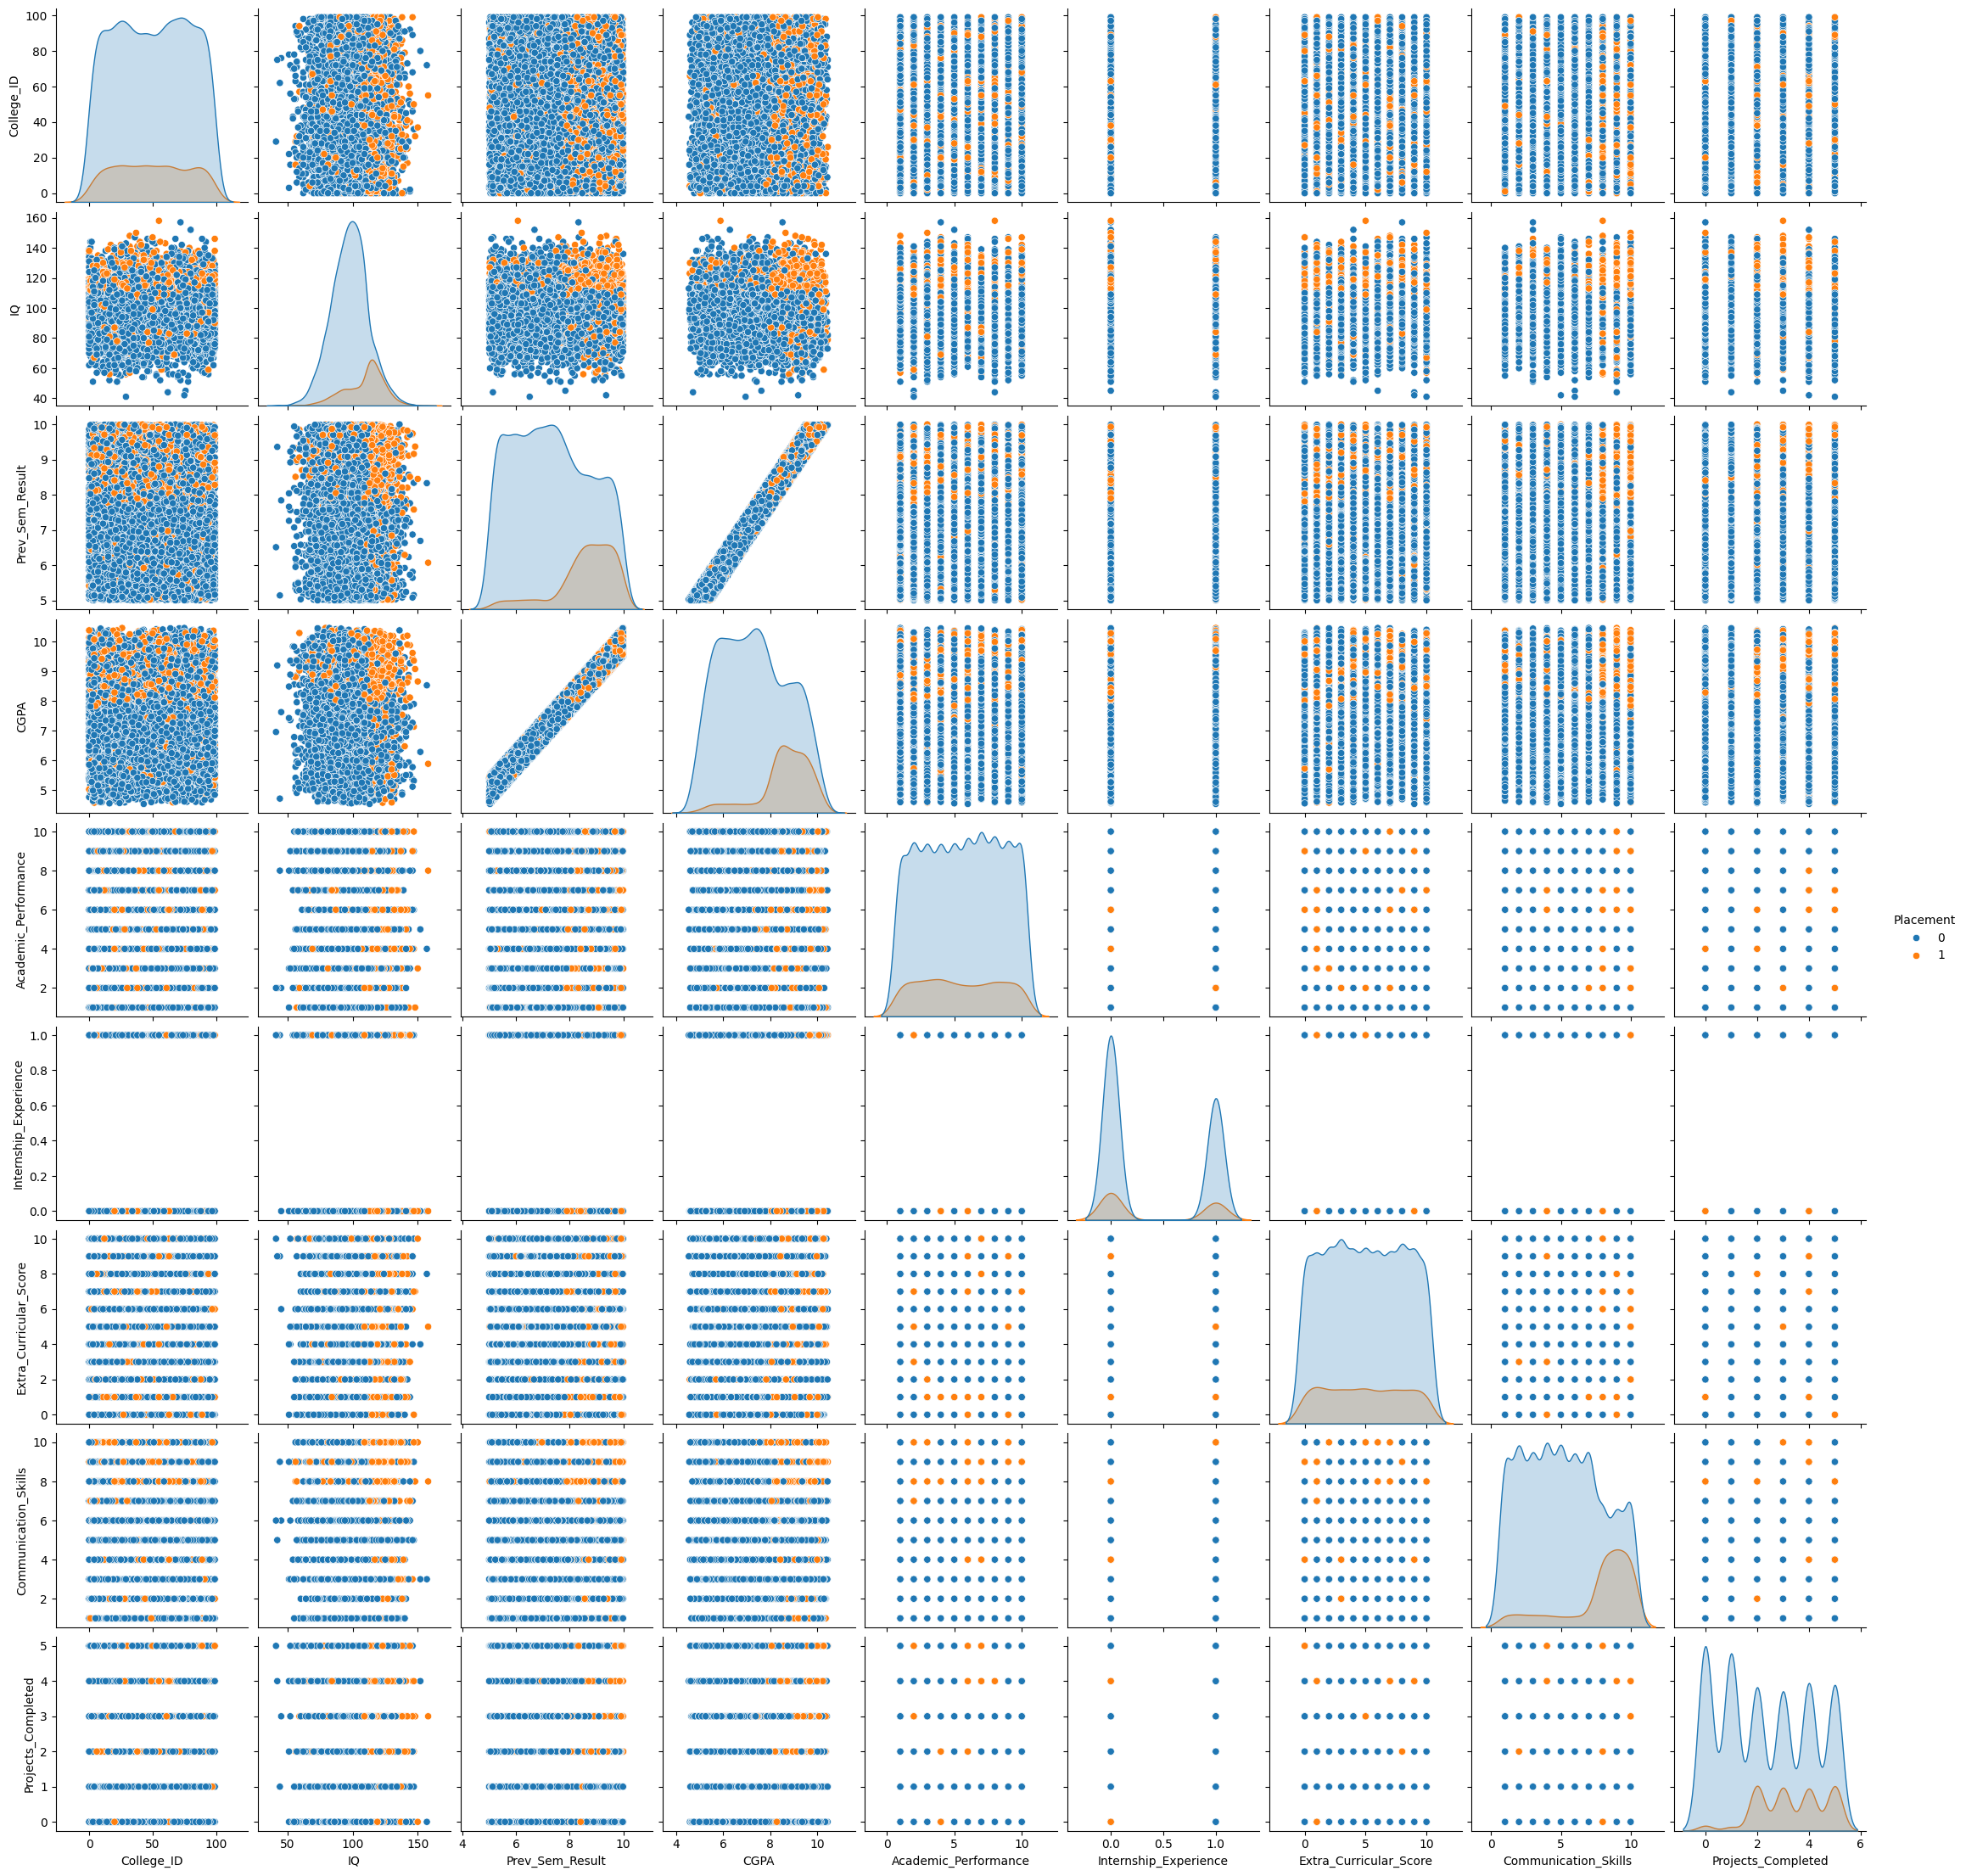

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = X.copy()
df_plot['Placement'] = y

sns.pairplot(df_plot, hue="Placement", diag_kind="kde")
plt.show()


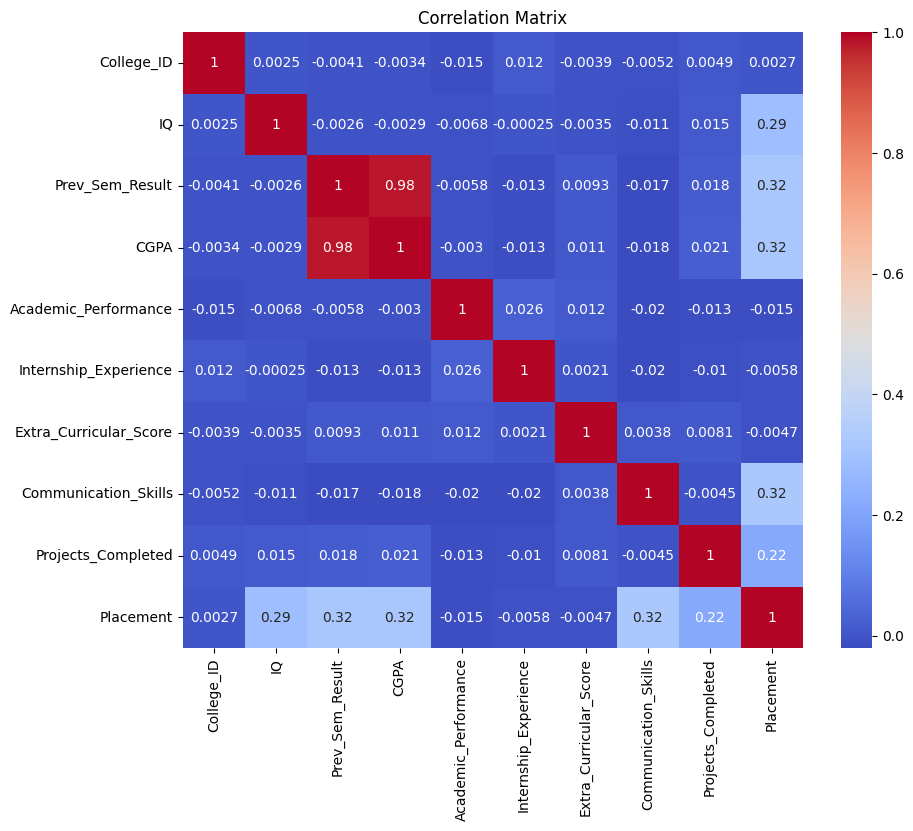

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_plot.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

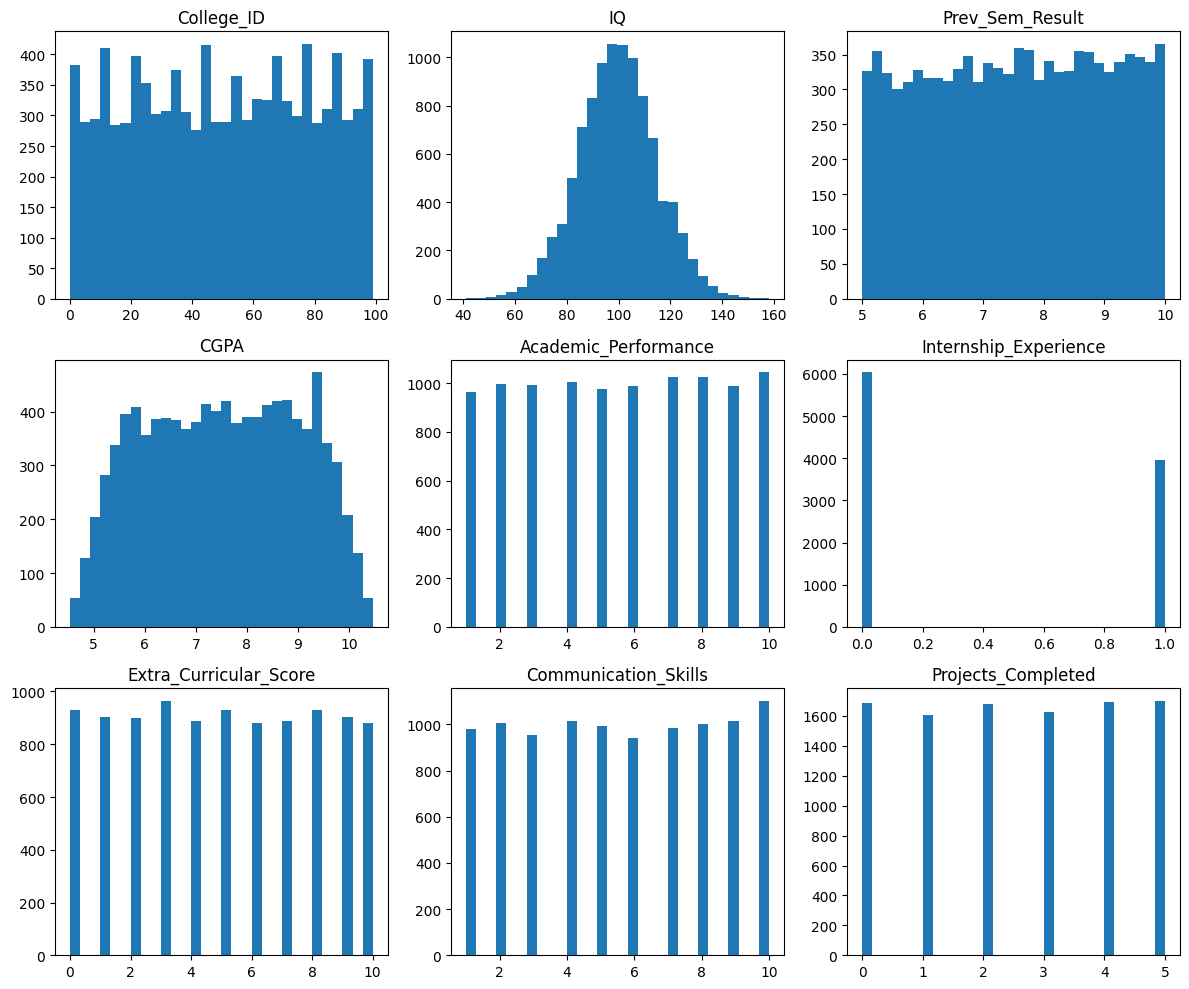

In [6]:

features = X.columns
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.hist(X[col], bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()


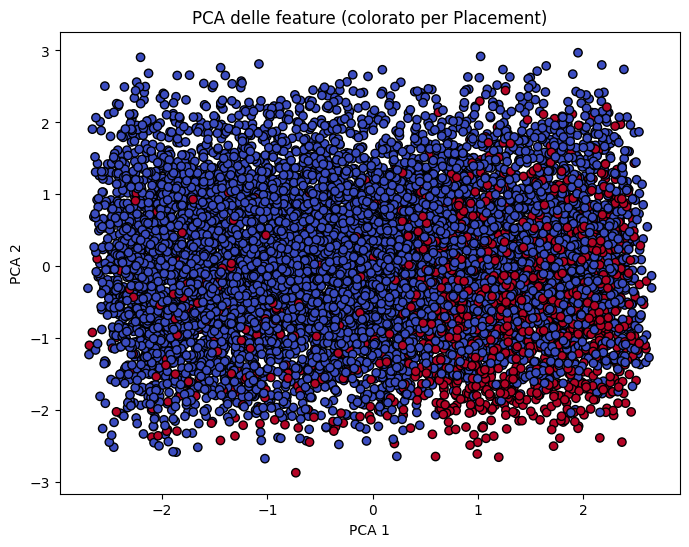

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA delle feature (colorato per Placement)")
plt.show()



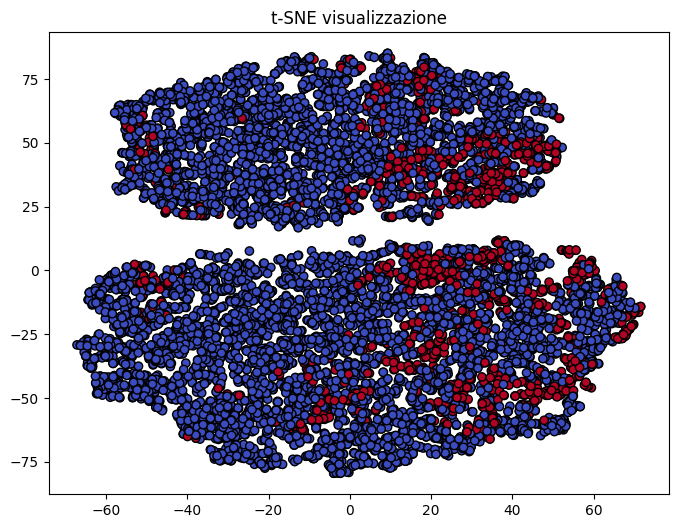

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='coolwarm', edgecolors='k')
plt.title("t-SNE visualizzazione")
plt.show()


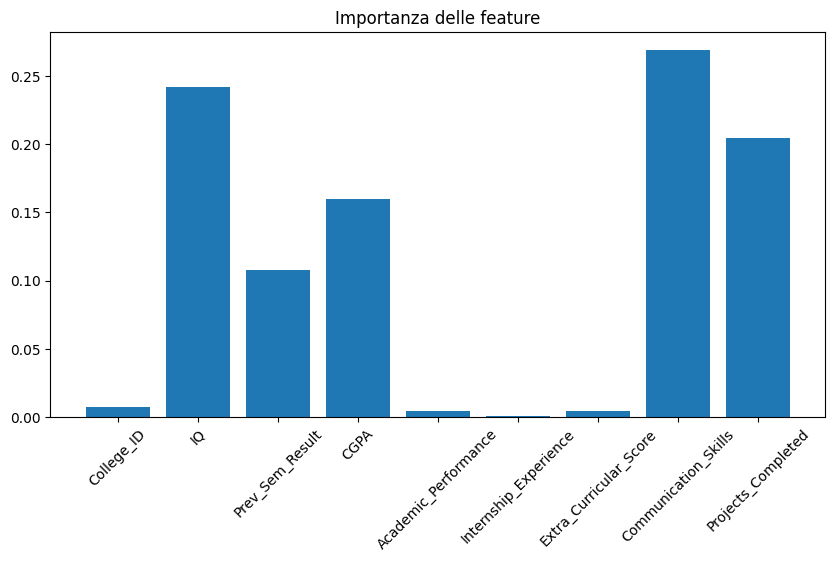

In [9]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X, y)

importances = clf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X.columns, importances)
plt.xticks(rotation=45)
plt.title("Importanza delle feature")
plt.show()


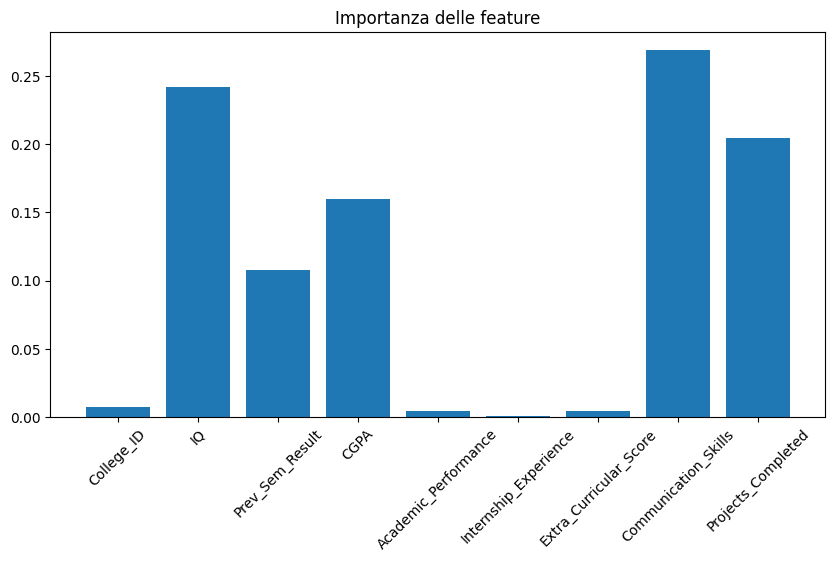

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)


clf = RandomForestClassifier(random_state=42)
clf.fit(X_normalized, y)

importances = clf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(X_normalized.columns, importances)
plt.xticks(rotation=45)
plt.title("Importanza delle feature")
plt.show()

**Classifiers definition**

In [11]:
features_to_use = ["IQ", "Communication_Skills", "Projects_Completed", "Prev_Sem_Result", "CGPA"]
X_selected = X_normalized[features_to_use].values  # array NumPy pronto per scikit-learn
y = df['Placement'].values  # target


# 1) Definisco i nomi dei classificatori mediante una lista di righe "names"
names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

# Creo le istanze dei classificatori inizializzando i parametri:
#    a) random_state=42: fisso la casualità per riproducibilità;
#    b) KNeighborsClassifier(3): uso k=3;
#    c) SVC(kernel="linear", C=0.025): SVM lineare con forte regolarizzazione (C piccolo);
#    d) SVC(gamma=2, C=1): SVM RBF (non lineare);
#    e) GaussianProcessClassifier(1.0 * RBF(1.0)): GPC con kernel RBF;
#    f) MLPClassifier(alpha=1, max_iter=1000): rete neurale con regolarizzazione L2 e massimo 1000 iterazioni;
#    g) RandomForestClassifier(max_features=1): forza ogni albero a considerare 1 feature per split;
classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    # GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]


# divido in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.4, random_state=42
)

# addestramento e valutazione
for name, clf in zip(names, classifiers):
    # creiamo pipeline con StandardScaler (anche se X è già normalizzato)
    pipeline = make_pipeline(StandardScaler(), clf)
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(f"{name}: Accuracy = {score:.2f}")


Nearest Neighbors: Accuracy = 0.98
Linear SVM: Accuracy = 0.90
RBF SVM: Accuracy = 0.98
Gaussian Process: Accuracy = 1.00
Decision Tree: Accuracy = 0.98
Random Forest: Accuracy = 0.94
Neural Net: Accuracy = 1.00
AdaBoost: Accuracy = 0.90
Naive Bayes: Accuracy = 0.92


In [12]:
from sklearn.metrics import classification_report

# divido in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.4, random_state=42
)

# addestramento e valutazione
for name, clf in zip(names, classifiers):
    pipeline = make_pipeline(StandardScaler(), clf)
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))

=== Nearest Neighbors ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3368
           1       0.94      0.91      0.92       632

    accuracy                           0.98      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.98      0.98      0.98      4000

=== Linear SVM ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3368
           1       0.77      0.55      0.64       632

    accuracy                           0.90      4000
   macro avg       0.84      0.76      0.79      4000
weighted avg       0.90      0.90      0.90      4000

=== RBF SVM ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3368
           1       0.97      0.92      0.95       632

    accuracy                           0.98      4000
   macro avg       0.98      0.96      0.97      4000
weighted avg 

# GridSearchCV Implementation
## Hyperparameter Tuning for Each Classifier (Expanded)

In [13]:
from sklearn.model_selection import GridSearchCV

print("Starting GridSearchCV for each classifier with expanded parameters...")

for clf in classifiers:
    clf_type = type(clf).__name__
    grid = {}
    
    if clf_type == "KNeighborsClassifier":
        grid = {
            "kneighborsclassifier__n_neighbors": [3, 5, 7, 9],
            "kneighborsclassifier__weights": ["uniform", "distance"],
            "kneighborsclassifier__metric": ["euclidean", "manhattan", "minkowski"]
        }
    elif clf_type == "SVC":
        if clf.kernel == "linear":
            grid = {
                "svc__C": [0.01, 0.1, 1, 10]
            }
            clf_type = "Linear SVM"
        else:
            grid = {
                "svc__gamma": [1, 0.1, 0.01, "scale", "auto"],
                "svc__C": [0.1, 1, 10, 100]
            }
            clf_type = "RBF SVM"
    elif clf_type == "DecisionTreeClassifier":
        grid = {
            "decisiontreeclassifier__max_depth": [3, 5, 10, 20, None],
            "decisiontreeclassifier__criterion": ["gini", "entropy"],
            "decisiontreeclassifier__min_samples_split": [2, 5, 10],
            "decisiontreeclassifier__min_samples_leaf": [1, 2, 4]
        }
    elif clf_type == "RandomForestClassifier":
        grid = {
            "randomforestclassifier__max_depth": [None, 10, 20],
            "randomforestclassifier__n_estimators": [50, 100, 200],
            "randomforestclassifier__min_samples_split": [2, 5, 10],
            "randomforestclassifier__min_samples_leaf": [1, 2, 4],
            "randomforestclassifier__bootstrap": [True, False],
            "randomforestclassifier__max_features": [1, "sqrt"]
        }
    elif clf_type == "MLPClassifier":
        grid = {
            "mlpclassifier__alpha": [0.0001, 0.001, 0.01],
            "mlpclassifier__max_iter": [1000],
            "mlpclassifier__activation": ["tanh", "relu"],
            "mlpclassifier__solver": ["sgd", "adam"],
            "mlpclassifier__learning_rate": ["constant", "adaptive"]
        }
    elif clf_type == "AdaBoostClassifier":
        grid = {
            "adaboostclassifier__n_estimators": [50, 100, 200],
            "adaboostclassifier__learning_rate": [0.01, 0.1, 1.0]
        }
    elif clf_type == "GaussianNB":
        grid = {
            "gaussiannb__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
        }
    elif clf_type == "QuadraticDiscriminantAnalysis":
        grid = {
            "quadraticdiscriminantanalysis__reg_param": [0.0, 0.1, 0.3, 0.5]
        }
    
    pipeline = make_pipeline(StandardScaler(), clf)
    
    print(f"\n=== Optimizing {clf_type} ===")
    if not grid:
        print(f"No grid defined for {clf_type}, evaluating default parameters.")
        pipeline.fit(X_train, y_train)
    else:
        gs = GridSearchCV(pipeline, grid, cv=3, scoring='accuracy', n_jobs=-1)
        gs.fit(X_train, y_train)
        print(f"Best Parameters: {gs.best_params_}")
        print(f"Best CV Accuracy: {gs.best_score_:.3f}")
        pipeline = gs.best_estimator_
    
    print("Test Set Evaluation:")
    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))

Starting GridSearchCV for each classifier with expanded parameters...

=== Optimizing KNeighborsClassifier ===
Best Parameters: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 9, 'kneighborsclassifier__weights': 'distance'}
Best CV Accuracy: 0.977
Test Set Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3368
           1       0.97      0.93      0.95       632

    accuracy                           0.98      4000
   macro avg       0.98      0.96      0.97      4000
weighted avg       0.98      0.98      0.98      4000


=== Optimizing Linear SVM ===
Best Parameters: {'svc__C': 0.1}
Best CV Accuracy: 0.900
Test Set Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3368
           1       0.77      0.58      0.66       632

    accuracy                           0.91      4000
   macro avg       0.85      0.77      0.8